# Análisis Exploratorio de Datos (EDA) - Predicción de incumplimieto de crédito (loan default prediction)

## Objetivo
Realizar un análisis exploratorio del dataset de incumplimiento de préstamos para:
- Comprender la estructura de los datos,
- Evaluar calidad y consistencia,
- Identificar valores faltantes y outliers,
- Detectar patrones relevantes entre variables explicativas y la variable objetivo `loan_status`.

Este análisis servirá como base para la etapa de preprocesamiento y posterior modelado predictivo.


## Imports

In [2]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

sns.set(style="whitegrid")

## Carga de datos

Se carga el dataset desde la carpeta `data/raw` para comenzar el análisis exploratorio.

In [3]:
df = pd.read_csv(r"..\data\raw\credit_risk_dataset.csv")

df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


## Inspección general del dataset

Se revisa la estructura general del dataset, incluyendo dimensiones y tipos de datos.

In [4]:
df.shape

(32581, 12)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  str    
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.0 MB


## Estadísticas descriptivas

Se analizan las variables numéricas para entender su comportamiento general.

In [6]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


## Descripción de variables del dataset

A continuación se describen las variables utilizadas en el análisis, clasificándolas según su tipo (numérica o categórica) y su significado:

### Variables numéricas

- **person_age**: Edad del solicitante (años).
- **person_income**: Ingreso anual del solicitante.
- **person_emp_length**: Años de experiencia laboral del solicitante.
- **loan_amnt**: Monto del préstamo solicitado.
- **loan_int_rate**: Tasa de interés del préstamo.
- **loan_percent_income**: Proporción del ingreso del solicitante comprometido por el préstamo.
- **cb_person_cred_hist_length**: Longitud del historial crediticio (años).

---

### Variables categóricas

- **person_home_ownership**: Tipo de vivienda del solicitante.
  - RENT: Arrienda
  - OWN: Propietario
  - MORTGAGE: Hipoteca
  - OTHER: Otro tipo

- **loan_intent**: Propósito del préstamo.
  - EDUCATION: Educación
  - MEDICAL: Gastos médicos
  - VENTURE: Negocio/emprendimiento
  - PERSONAL: Uso personal
  - DEBTCONSOLIDATION: Consolidación de deudas
  - HOMEIMPROVEMENT: Mejoras del hogar

- **loan_grade**: Clasificación del préstamo según riesgo crediticio.
  - A: Menor riesgo
  - B–G: Riesgo creciente (G es el más alto)

- **cb_person_default_on_file**: Historial previo de incumplimiento.
  - Y: Sí ha tenido incumplimientos
  - N: No ha tenido incumplimientos

---

### Variable objetivo

- **loan_status**: Estado del préstamo (variable objetivo).
  - 1: Incumplimiento (default)
  - 0: No incumplimiento

---

### Observación

Las variables numéricas permiten modelar relaciones cuantitativas, mientras que las variables categóricas aportan información cualitativa relevante sobre el perfil del solicitante. Estas últimas serán transformadas mediante técnicas de codificación (encoding) para su uso en modelos de aprendizaje automático.

## Valores faltantes

Se identifican valores nulos en el dataset para evaluar su impacto.

In [7]:
df.isnull().sum().sort_values(ascending=False)

loan_int_rate                 3116
person_emp_length              895
person_income                    0
person_age                       0
person_home_ownership            0
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [8]:
(df.isnull().mean() * 100).sort_values(ascending=False)

loan_int_rate                 9.563856
person_emp_length             2.747000
person_income                 0.000000
person_age                    0.000000
person_home_ownership         0.000000
loan_intent                   0.000000
loan_grade                    0.000000
loan_amnt                     0.000000
loan_status                   0.000000
loan_percent_income           0.000000
cb_person_default_on_file     0.000000
cb_person_cred_hist_length    0.000000
dtype: float64

### Observación
Se observan variables con valores faltantes que deberán ser tratadas en la etapa de preprocesamiento.

## Distribución de la variable objetivo

Se analiza la variable `loan_status` para entender el balance de clases.


In [9]:
df["loan_status"].value_counts()

loan_status
0    25473
1     7108
Name: count, dtype: int64

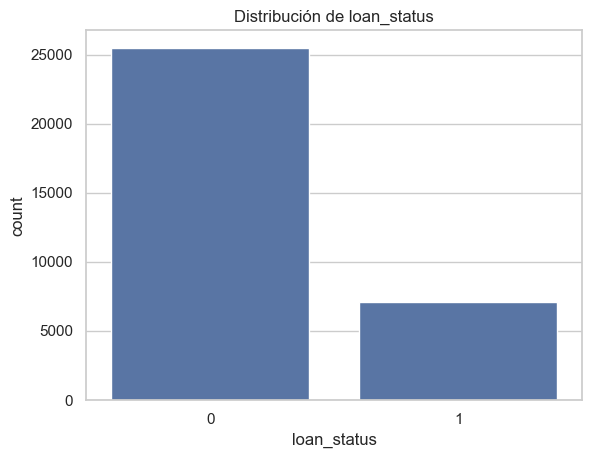

In [10]:
sns.countplot(data=df, x="loan_status")
plt.title("Distribución de loan_status")
plt.show()

### Observación
Existe desbalance entre clases, lo cual puede afectar el entrenamiento de modelos.

## Distribución de variables numéricas

Se visualizan histogramas para analizar la distribución de las variables numéricas.

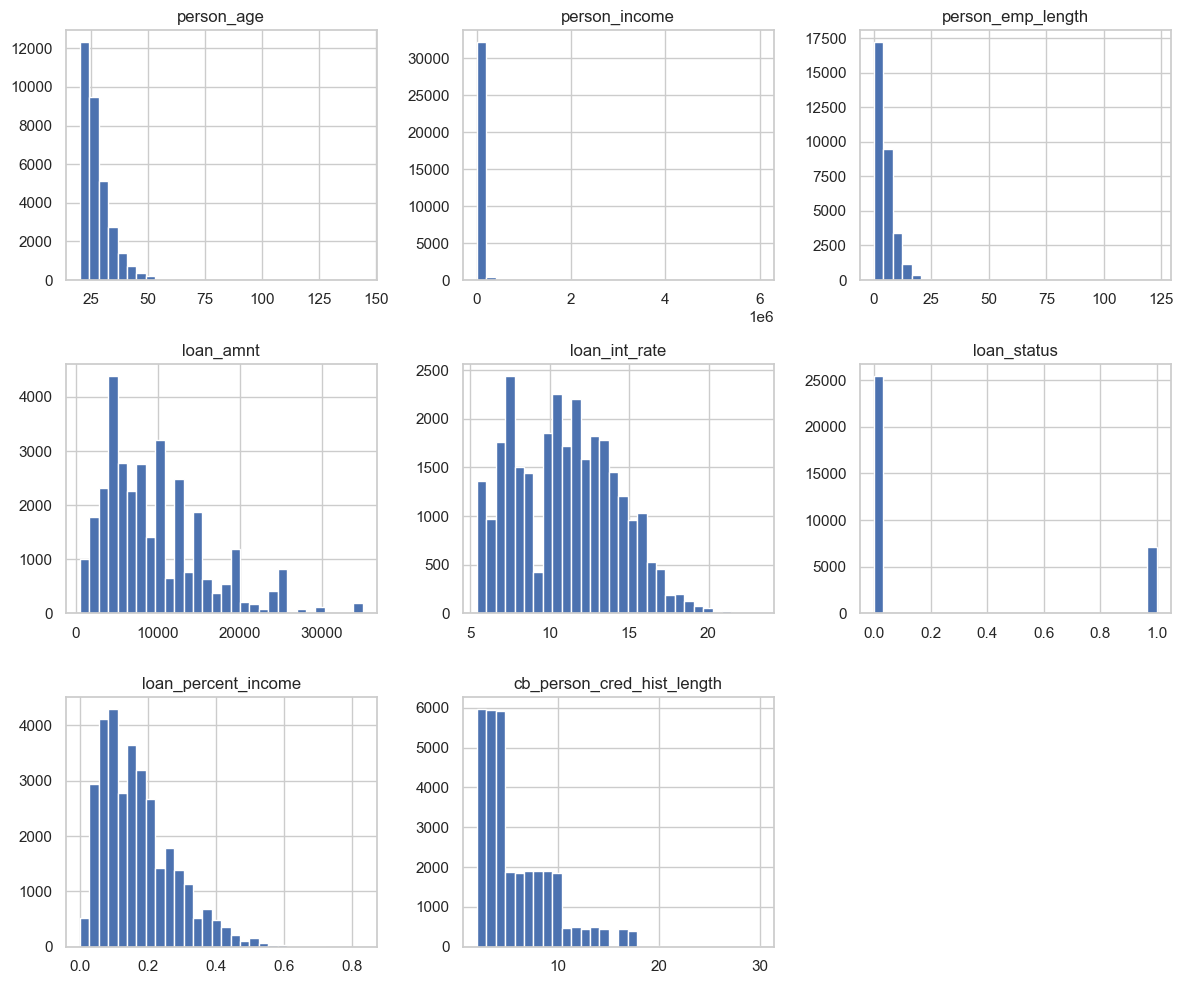

In [11]:
df.hist(figsize=(12, 10), bins=30)
plt.tight_layout()
plt.show()

## Detección de outliers

Se utilizan boxplots para identificar valores atípicos.

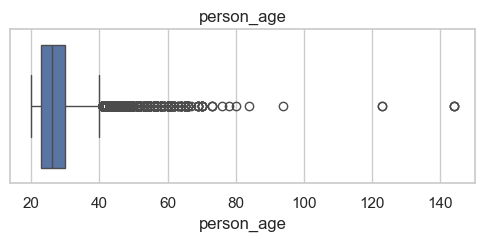

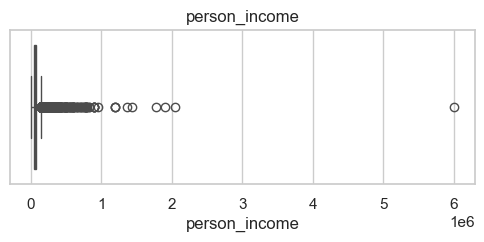

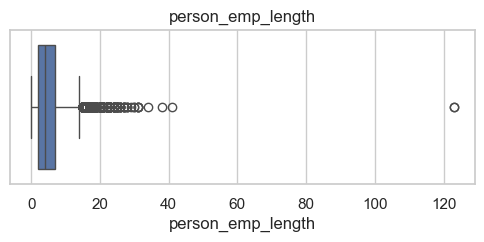

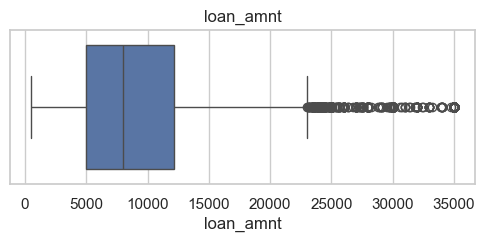

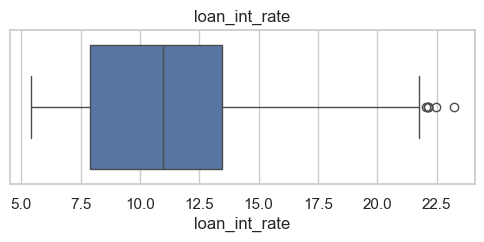

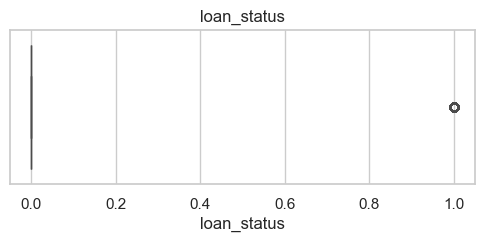

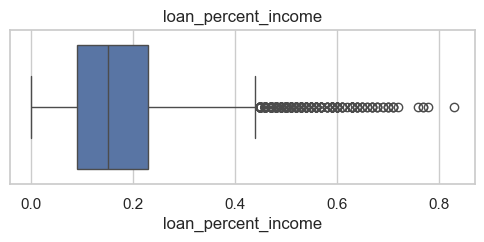

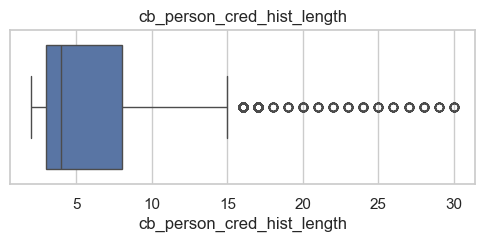

In [12]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns

for col in num_cols:
    plt.figure(figsize=(6, 2))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

### Observación

Se detectan valores extremos en variables como ingresos y montos de préstamo, los cuales deberán analizarse en el preprocesamiento.

## Relación entre variables y loan_status

Se analiza cómo algunas variables influyen en el incumplimiento.

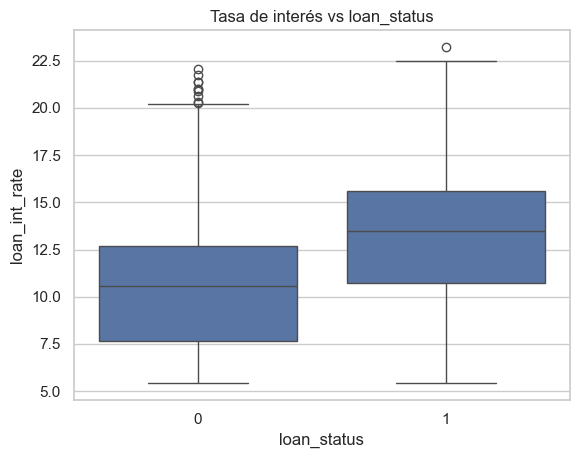

In [13]:
sns.boxplot(data=df, x="loan_status", y="loan_int_rate")
plt.title("Tasa de interés vs loan_status")
plt.show()

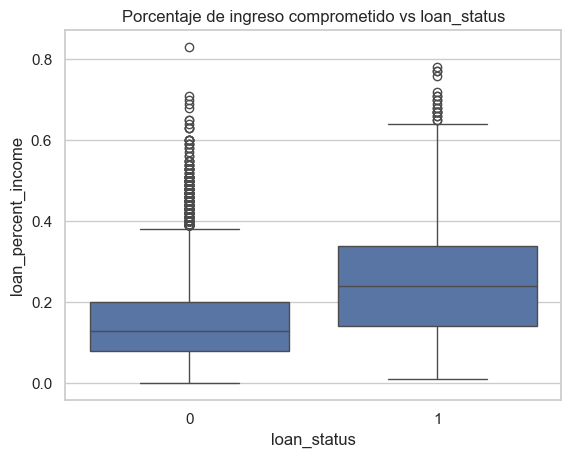

In [14]:
sns.boxplot(data=df, x="loan_status", y="loan_percent_income")
plt.title("Porcentaje de ingreso comprometido vs loan_status")
plt.show()

### Observación
Se observa que mayores tasas de interés y mayor proporción de ingreso comprometido se asocian con mayor probabilidad de incumplimiento en el pago del crédito.

## Variables categóricas

Se analizan variables categóricas en relación con la variable objetivo.

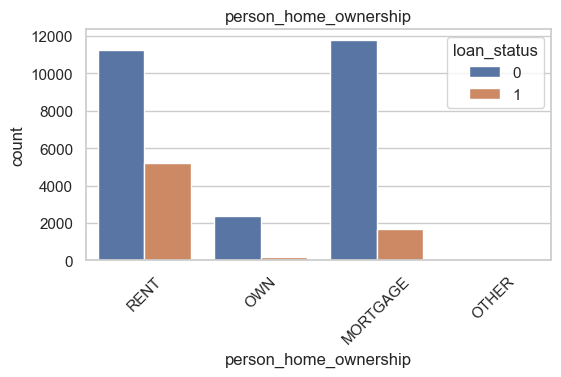

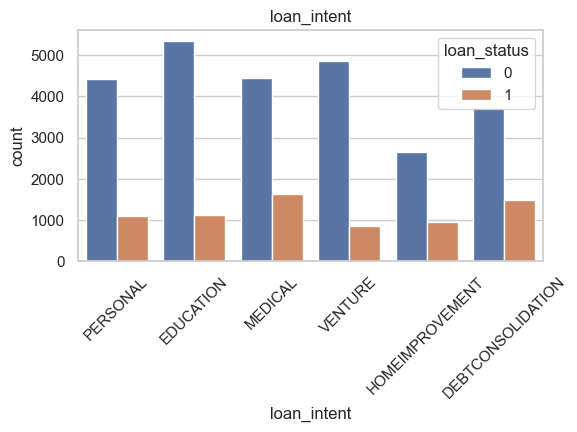

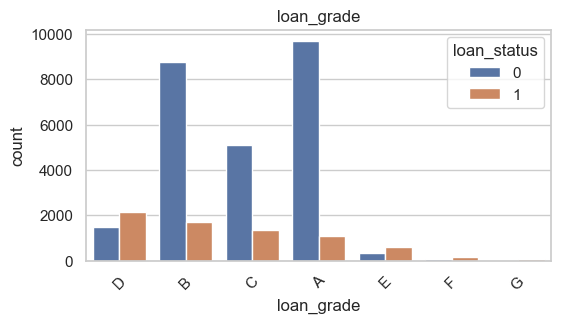

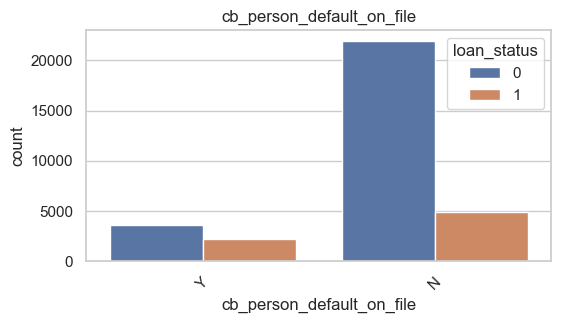

In [15]:
cat_cols = df.select_dtypes(include=["object"]).columns

for col in cat_cols:
    plt.figure(figsize=(6, 3))
    sns.countplot(data=df, x=col, hue="loan_status")
    plt.title(col)
    plt.xticks(rotation=45)
    plt.show()

### Observación
Algunas categorías muestran diferencias claras entre clientes con y sin incumplimiento.

## Correlación entre variables

Se analiza la relación entre variables numéricas.

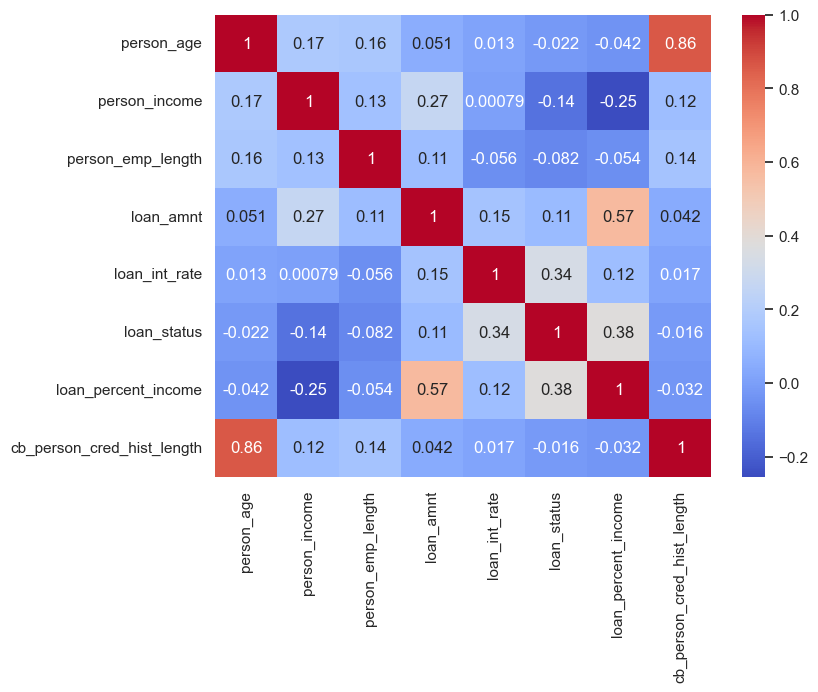

In [16]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()


## Conclusiones del análisis exploratorio

El análisis exploratorio permitió comprender en profundidad la estructura y calidad del dataset, así como identificar patrones relevantes para la predicción del incumplimiento de préstamos.

En primer lugar, se detectó la presencia de valores faltantes en algunas variables, lo que hizo necesario considerar técnicas de imputación en la etapa de preprocesamiento para evitar la pérdida de información relevante. Asimismo, se identificaron outliers en variables numéricas como ingresos, monto del préstamo y tasa de interés, los cuales podrían influir en el comportamiento del modelo, por lo que se evaluó su impacto antes de decidir su tratamiento.

En cuanto a la variable objetivo, se observa un cierto nivel de desbalance entre las clases, lo que puede afectar el rendimiento del modelo, especialmente en la detección de casos de incumplimiento. Este aspecto es importante ya que influye directamente en la elección de métricas y técnicas de modelado.

A partir del análisis de correlación, se identifican relaciones relevantes entre variables. Por ejemplo, `loan_percent_income` y `loan_int_rate` presentan una relación positiva con el incumplimiento, lo que sugiere que una mayor carga financiera y tasas de interés más elevadas están asociadas a un mayor riesgo. También se observa una relación entre la edad y la longitud del historial crediticio, lo cual podría implicar cierta redundancia de información.

Estos hallazgos permitieron orientar las decisiones de preprocesamiento y modelado, priorizando variables con mayor relevancia predictiva y considerando posibles transformaciones para mejorar el desempeño de los modelos.

En conjunto, el análisis exploratorio confirma que el dataset contiene señales útiles para abordar el problema de clasificación y sienta las bases para una etapa de modelado más informada.


## Preprocesamiento de datos

En esta sección se preparan los datos para el modelado:
- Tratamiento de valores faltantes
- Codificación de variables categóricas
- Escalamiento de variables numéricas
- Partición en conjuntos de entrenamiento y prueba

Se evita fuga de información aplicando transformaciones **solo a los datos de entrenamiento**.

### Selección de variables

Se define la variable objetivo (`loan_status`) y el conjunto de variables explicativas.

In [17]:
target = "loan_status"

X = df.drop(columns=[target])
y = df[target].copy()

X.shape, y.shape

((32581, 11), (32581,))

### División en entrenamiento y prueba

Se divide el dataset para evitar fuga de información durante el preprocesamiento.

In [18]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # mantiene proporción de clases
)

X_train.shape, X_test.shape

((26064, 11), (6517, 11))

### Identificación de variables numéricas y categóricas

In [19]:
num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X_train.select_dtypes(include=["object"]).columns.tolist()

num_cols, cat_cols

(['person_age',
  'person_income',
  'person_emp_length',
  'loan_amnt',
  'loan_int_rate',
  'loan_percent_income',
  'cb_person_cred_hist_length'],
 ['person_home_ownership',
  'loan_intent',
  'loan_grade',
  'cb_person_default_on_file'])

### Tratamiento de valores faltantes

- Numéricas: imputación con mediana  
- Categóricas: imputación con moda (más frecuente)

In [20]:
# Crear imputadores:
# - mediana para variables numéricas (robusto a outliers)
# - valor más frecuente para variables categóricas
num_imputer = SimpleImputer(strategy="median")
cat_imputer = SimpleImputer(strategy="most_frequent")

# Ajustar imputador numérico SOLO con entrenamiento y transformar
X_train_num = pd.DataFrame(
    num_imputer.fit_transform(X_train[num_cols]),  # aprende y aplica
    columns=num_cols,
    index=X_train.index
)

# Aplicar imputación al test (sin volver a ajustar)
X_test_num = pd.DataFrame(
    num_imputer.transform(X_test[num_cols]),
    columns=num_cols,
    index=X_test.index
)

# Ajustar imputador categórico SOLO con entrenamiento y transformar
X_train_cat = pd.DataFrame(
    cat_imputer.fit_transform(X_train[cat_cols]),
    columns=cat_cols,
    index=X_train.index
)

# Aplicar imputación categórica al test
X_test_cat = pd.DataFrame(
    cat_imputer.transform(X_test[cat_cols]),
    columns=cat_cols,
    index=X_test.index
)

### Codificación de variables categóricas

Se aplica One-Hot Encoding para transformar variables categóricas en variables numéricas.

In [21]:
from sklearn.preprocessing import OneHotEncoder

# Crear encoder para variables categóricas
# handle_unknown="ignore" evita errores si aparece una categoría nueva en test
# sparse_output=False devuelve un array denso (no disperso)
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

# Ajustar encoder con datos de entrenamiento y transformar
X_train_cat_enc = pd.DataFrame(
    encoder.fit_transform(X_train_cat),  # aprende categorías y transforma
    columns=encoder.get_feature_names_out(cat_cols),  # nombres de nuevas columnas
    index=X_train.index
)

# Aplicar transformación al conjunto de prueba (sin volver a ajustar)
X_test_cat_enc = pd.DataFrame(
    encoder.transform(X_test_cat),
    columns=encoder.get_feature_names_out(cat_cols),
    index=X_test.index
)

### Escalamiento de variables numéricas

Se aplica StandardScaler para normalizar las variables numéricas.

In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_num_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_num),
    columns=num_cols,
    index=X_train.index
)

X_test_num_scaled = pd.DataFrame(
    scaler.transform(X_test_num),
    columns=num_cols,
    index=X_test.index
)

### Construcción del dataset final

In [23]:
X_train_final = pd.concat([X_train_num_scaled, X_train_cat_enc], axis=1)
X_test_final = pd.concat([X_test_num_scaled, X_test_cat_enc], axis=1)

X_train_final.shape, X_test_final.shape

((26064, 26), (6517, 26))

### Verificación del dataset

In [24]:
X_train_final.head()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_MORTGAGE,person_home_ownership_OTHER,person_home_ownership_OWN,...,loan_intent_VENTURE,loan_grade_A,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_N,cb_person_default_on_file_Y
15884,-0.427163,2.759666,-0.187630,1.021455,-1.288396,-0.937956,-0.442817,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
15138,-1.059358,-0.754040,0.055383,-1.281664,0.379327,-0.844328,-0.442817,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
7474,-0.427163,-0.204717,1.270449,1.021455,0.493109,1.215493,-0.938514,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
18212,0.046983,-0.772874,-0.187630,-0.725739,0.964493,1.215493,0.548578,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
6493,-0.427163,-0.251802,-0.673657,0.068440,-1.012068,0.279211,-0.938514,1.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [25]:
X_train_final.isnull().sum().sum()

np.int64(0)

### Exportación de datos procesados

Se guardan los datasets para su uso en el modelado.

In [26]:
import os
os.makedirs(r"..\data\processed", exist_ok=True)

X_train_final.to_csv(r"..\data\processed\X_train.csv", index=False)
X_test_final.to_csv(r"..\data\processed\X_test.csv", index=False)
y_train.to_csv(r"..\data\processed\y_train.csv", index=False)
y_test.to_csv(r"..\data\processed\y_test.csv", index=False)

## Modelado

En esta sección se entrenan distintos modelos de clasificación para predecir el incumplimiento de préstamos.

Se seleccionan modelos representativos del aprendizaje supervisado:
- Regresión Logística
- Árbol de Decisión
- Random Forest

El objetivo es comparar su desempeño utilizando métricas adecuadas.

### Definición de modelos y funciones de evaluación

#### Importación de modelos y métricas

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

#### Función para entrenamiento y evaluación de modelos

In [28]:
def evaluar_modelo(nombre, modelo, X_train, X_test, y_train, y_test):
    # Entrenar el modelo con los datos de entrenamiento
    modelo.fit(X_train, y_train)
    
    # Generar predicciones sobre el conjunto de prueba
    y_pred = modelo.predict(X_test)
    
    # Obtener probabilidades para la clase positiva (default = 1)
    y_proba = modelo.predict_proba(X_test)[:, 1]

    # Calcular métricas de evaluación
    resultados = {
        "Modelo": nombre,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC_AUC": roc_auc_score(y_test, y_proba)
    }

    # Mostrar resultados por pantalla
    print(f"\n=== {nombre} ===")
    print(classification_report(y_test, y_pred))

    # Retornar métricas en formato diccionario
    return resultados

### Modelo 1: Regresión Logística

Modelo interpretable que permite establecer una línea base de comparación.

In [29]:
modelo_lr = LogisticRegression(max_iter=1000)

res_lr = evaluar_modelo(
    "Logistic Regression",
    modelo_lr,
    X_train_final,
    X_test_final,
    y_train,
    y_test
)


=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.89      0.95      0.92      5095
           1       0.77      0.56      0.65      1422

    accuracy                           0.87      6517
   macro avg       0.83      0.76      0.78      6517
weighted avg       0.86      0.87      0.86      6517



### Interpretación de resultados - Regresión Logística

El modelo de regresión logística muestra una accuracy de 0.87, lo que en principio parece indicar un buen desempeño general. Sin embargo, al analizar las métricas con más detalle, se observan diferencias importantes entre las clases.

En el caso de los clientes que no incumplen (clase 0), el modelo funciona bastante bien. Logra identificar correctamente la gran mayoría de estos casos, con un recall de 0.95 y un F1-score de 0.92, lo que refleja un comportamiento sólido para esta clase.

Por otro lado, la situación cambia al analizar la clase 1, que corresponde a los clientes que sí incumplen. Aquí el recall es de 0.56, lo que significa que el modelo solo logra detectar un poco más de la mitad de los incumplimientos reales. En otras palabras, una proporción importante de clientes de riesgo no está siendo identificada.

Esto es especialmente relevante, ya que en este tipo de problemas el foco principal está justamente en detectar los casos de incumplimiento. Por lo tanto, aunque la accuracy global sea alta, el modelo no está cumpliendo completamente con el objetivo del problema.

En síntesis, la regresión logística funciona como un buen punto de partida, pero presenta limitaciones importantes para identificar correctamente a los clientes con mayor riesgo, lo que justifica la necesidad de aplicar técnicas adicionales o modelos más avanzados.

### Árbol de Decisión

Modelo basado en reglas que permite capturar relaciones no lineales.

In [30]:
modelo_dt = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

res_dt = evaluar_modelo(
    "Decision Tree",
    modelo_dt,
    X_train_final,
    X_test_final,
    y_train,
    y_test
)


=== Decision Tree ===
              precision    recall  f1-score   support

           0       0.89      1.00      0.94      5095
           1       0.98      0.55      0.71      1422

    accuracy                           0.90      6517
   macro avg       0.93      0.78      0.82      6517
weighted avg       0.91      0.90      0.89      6517



### Interpretación de resultados - Árbol de Decisión

El modelo de árbol de decisión presenta una accuracy de 0.90, lo que representa una mejora respecto a la regresión logística. A simple vista, esto podría interpretarse como un mejor desempeño general del modelo.

Al analizar la clase 0 (clientes que no incumplen), el modelo obtiene resultados muy altos, con un recall cercano a 1.00 y un F1-score de 0.94, lo que indica que prácticamente todos estos casos son correctamente identificados.

En el caso de la clase 1 (clientes que incumplen), el modelo muestra un comportamiento mixto. Por un lado, la precisión es muy alta (0.98), lo que significa que cuando el modelo predice que un cliente incumplirá, casi siempre acierta. Sin embargo, el recall es de 0.55, lo que indica que solo logra detectar poco más de la mitad de los incumplimientos reales.

Esto sugiere que el modelo es bastante conservador al momento de clasificar casos como incumplimiento: prefiere evitar falsos positivos, pero a costa de dejar pasar varios casos de riesgo.

En términos generales, el árbol de decisión mejora la precisión respecto a la regresión logística, pero mantiene la misma limitación en la detección de incumplimientos. Por esta razón, aunque el modelo presenta un buen desempeño global, aún no es completamente adecuado para el objetivo del problema.

### Random Forest

Modelo ensemble que mejora la estabilidad y precisión mediante múltiples árboles.

In [31]:
modelo_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

res_rf = evaluar_modelo(
    "Random Forest",
    modelo_rf,
    X_train_final,
    X_test_final,
    y_train,
    y_test
)


=== Random Forest ===
              precision    recall  f1-score   support

           0       0.93      0.99      0.96      5095
           1       0.97      0.72      0.83      1422

    accuracy                           0.93      6517
   macro avg       0.95      0.86      0.89      6517
weighted avg       0.94      0.93      0.93      6517



### Interpretación de resultados - Random Forest

El modelo Random Forest presenta una accuracy de 0.93, superando a los modelos anteriores y mostrando un mejor desempeño general.

En el caso de la clase 0 (clientes que no incumplen), el modelo mantiene resultados muy altos, con un recall de 0.99 y un F1-score de 0.96, lo que indica que identifica correctamente casi todos los casos sin incumplimiento.

Lo más relevante se observa en la clase 1 (clientes que incumplen), donde el modelo alcanza un recall de 0.72, mejorando de forma considerable respecto a la regresión logística y el árbol de decisión. Esto significa que el modelo logra detectar una mayor proporción de incumplimientos reales, reduciendo la cantidad de casos de riesgo que pasan desapercibidos.

Además, la precisión para esta clase es de 0.97, lo que indica que cuando el modelo predice un incumplimiento, la mayoría de las veces es correcto. Esto refleja un buen equilibrio entre detectar casos de riesgo y evitar falsos positivos.

En conjunto, el modelo Random Forest logra un mejor balance entre precisión y recall, lo que se traduce en un F1-score más alto (0.83) para la clase de incumplimiento.

En conclusión, este modelo presenta el mejor desempeño entre los evaluados, siendo más adecuado para el problema, ya que mejora significativamente la detección de clientes con riesgo de incumplimiento sin sacrificar demasiado la precisión.

## Comparación de modelos

Se comparan los modelos en base a métricas de desempeño.

In [32]:
resultados = pd.DataFrame([res_lr, res_dt, res_rf])
resultados.sort_values(by="F1", ascending=False)

,Modelo,Accuracy,Precision,Recall,F1,ROC_AUC
2,Random Forest,0.933712,0.970532,0.718003,0.825384,0.929216
1,Decision Tree,0.899647,0.975248,0.554149,0.706726,0.872756
0,Logistic Regression,0.867117,0.766795,0.561885,0.648539,0.869339


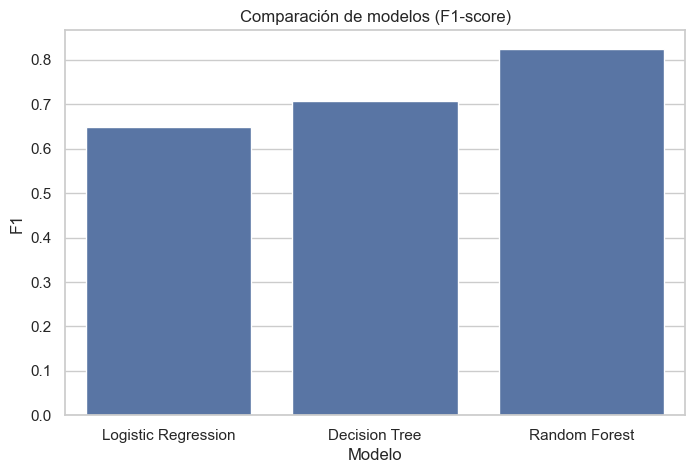

In [33]:
plt.figure(figsize=(8, 5))
sns.barplot(data=resultados, x="Modelo", y="F1")
plt.title("Comparación de modelos (F1-score)")
plt.show()

## Evaluación del mejor modelo

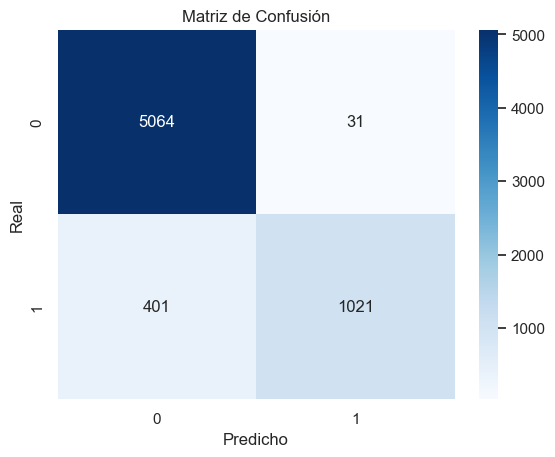

In [34]:
best_model = modelo_rf  
y_pred_best = best_model.predict(X_test_final)

cm = confusion_matrix(y_test, y_pred_best)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión")
plt.show()

## Conclusiones del modelado

A partir de los resultados obtenidos, se observa que el modelo Random Forest presenta el mejor desempeño general en comparación con la regresión logística y el árbol de decisión. Mientras que la regresión logística logra un desempeño más limitado al capturar principalmente relaciones lineales, y el árbol de decisión tiende a sobreajustarse a los datos, Random Forest logra una mejor generalización al combinar múltiples árboles, capturando relaciones más complejas.

El análisis de métricas muestra que Random Forest alcanza un mejor equilibrio entre precisión y recall, reflejado en un F1-score superior, especialmente en la clase de incumplimiento. Esto es fundamental, ya que el objetivo principal del modelo es identificar correctamente a los clientes con mayor riesgo.

A partir de la matriz de confusión, se observa que el modelo clasifica correctamente la mayoría de los casos, con pocos falsos positivos. Sin embargo, aún existen falsos negativos (clientes que incumplen pero no son detectados), lo cual representa un riesgo importante desde el punto de vista del negocio, ya que implica otorgar créditos a clientes que podrían no cumplir con sus pagos, generando potenciales pérdidas económicas.

Si bien el desempeño del modelo es sólido, estos resultados deben analizarse considerando el desbalance de clases presente en el dataset, lo que puede dificultar la correcta identificación de todos los casos de incumplimiento.

En general, el modelo Random Forest se posiciona como la mejor alternativa dentro de los evaluados, logrando un buen desempeño y una adecuada capacidad de generalización, aunque aún existe margen de mejora, especialmente en la reducción de falsos negativos.



## Propuesta de mejoras

A partir de los resultados obtenidos, es posible identificar algunas oportunidades de mejora para el modelo.

En primer lugar, se podría aplicar técnicas de balanceo de clases, como SMOTE o submuestreo, con el objetivo de mejorar la detección de casos de incumplimiento y reducir la cantidad de falsos negativos.

En segundo lugar, sería recomendable realizar una optimización de hiperparámetros del modelo Random Forest, ajustando variables como la profundidad de los árboles, número de estimadores y criterios de división, con el fin de mejorar su desempeño.

Adicionalmente, se podría explorar la incorporación de nuevas variables derivadas (feature engineering), que permitan capturar mejor la relación entre el ingreso del cliente y la carga del préstamo.

Finalmente, también sería interesante evaluar otros modelos más complejos o técnicas de ensamblado adicionales, con el objetivo de comparar si es posible obtener mejoras significativas en el rendimiento.

### Balanceo de clases

Se aplica SMOTE para corregir el desbalance de la variable objetivo.

In [35]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train_final, y_train)

print("Antes:", y_train.value_counts())
print("Después:", pd.Series(y_train_smote).value_counts())

Antes: loan_status
0    20378
1     5686
Name: count, dtype: int64
Después: loan_status
0    20378
1    20378
Name: count, dtype: int64


Entrenar nuevamente con datos balanceados

In [36]:
modelo_rf_smote = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

res_rf_smote = evaluar_modelo(
    "Random Forest (SMOTE)",
    modelo_rf_smote,
    X_train_smote,
    X_test_final,
    y_train_smote,
    y_test
)


=== Random Forest (SMOTE) ===
              precision    recall  f1-score   support

           0       0.93      0.99      0.96      5095
           1       0.94      0.73      0.82      1422

    accuracy                           0.93      6517
   macro avg       0.93      0.86      0.89      6517
weighted avg       0.93      0.93      0.93      6517



### Optimización de hiperparámetros

Se utiliza GridSearch para encontrar la mejor configuración del modelo.

In [37]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring="f1",
    n_jobs=-1
)

grid.fit(X_train_smote, y_train_smote)

grid.best_params_

{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}

Evaluar mejor modelo

In [38]:
best_rf = grid.best_estimator_

res_rf_tuned = evaluar_modelo(
    "Random Forest Optimizado",
    best_rf,
    X_train_smote,
    X_test_final,
    y_train_smote,
    y_test
)


=== Random Forest Optimizado ===
              precision    recall  f1-score   support

           0       0.93      0.99      0.96      5095
           1       0.94      0.73      0.82      1422

    accuracy                           0.93      6517
   macro avg       0.93      0.86      0.89      6517
weighted avg       0.93      0.93      0.93      6517



## Comparación final de modelos

In [39]:
resultados_final = pd.DataFrame([
    res_lr,
    res_dt,
    res_rf,
    res_rf_smote,
    res_rf_tuned
])

resultados_final.sort_values(by="F1", ascending=False)

,Modelo,Accuracy,Precision,Recall,F1,ROC_AUC
2,Random Forest,0.933712,0.970532,0.718003,0.825384,0.929216
3,Random Forest (SMOTE),0.930796,0.940163,0.729255,0.821386,0.928524
4,Random Forest Optimizado,0.929876,0.936652,0.727848,0.819153,0.930009
1,Decision Tree,0.899647,0.975248,0.554149,0.706726,0.872756
0,Logistic Regression,0.867117,0.766795,0.561885,0.648539,0.869339


### Conclusión de la etapa de mejora del modelo

Tras aplicar técnicas de balanceo de clases (SMOTE) y optimización de hiperparámetros, se observa que el modelo Random Forest mantiene el mejor desempeño general entre las alternativas evaluadas.

Si bien el uso de SMOTE permitió mejorar ligeramente el recall de la clase de incumplimiento, este incremento se da a costa de una leve disminución en la precisión y en la accuracy. De forma similar, la optimización del modelo no generó mejoras significativas respecto a la versión base.

En este contexto, el modelo Random Forest original presenta el mejor equilibrio entre precisión y recall, alcanzando el mayor F1-score, lo que lo posiciona como la mejor opción para el problema.

En conclusión, las mejoras aplicadas permiten validar la robustez del modelo seleccionado, confirmando que ya ofrece un desempeño adecuado sin necesidad de modificaciones adicionales complejas.

### Importancia de variables

Se identifican las variables más relevantes del modelo.

In [40]:
importances = best_rf.feature_importances_

feat_importance = pd.DataFrame({
    "feature": X_train_final.columns,
    "importance": importances
}).sort_values(by="importance", ascending=False)

feat_importance.head(10)

,feature,importance
5,loan_percent_income,0.198858
1,person_income,0.128447
4,loan_int_rate,0.118690
3,loan_amnt,0.069986
20,loan_grade_D,0.058619
2,person_emp_length,0.058335
6,cb_person_cred_hist_length,0.051899
10,person_home_ownership_RENT,0.051889
0,person_age,0.049643
7,person_home_ownership_MORTGAGE,0.024361


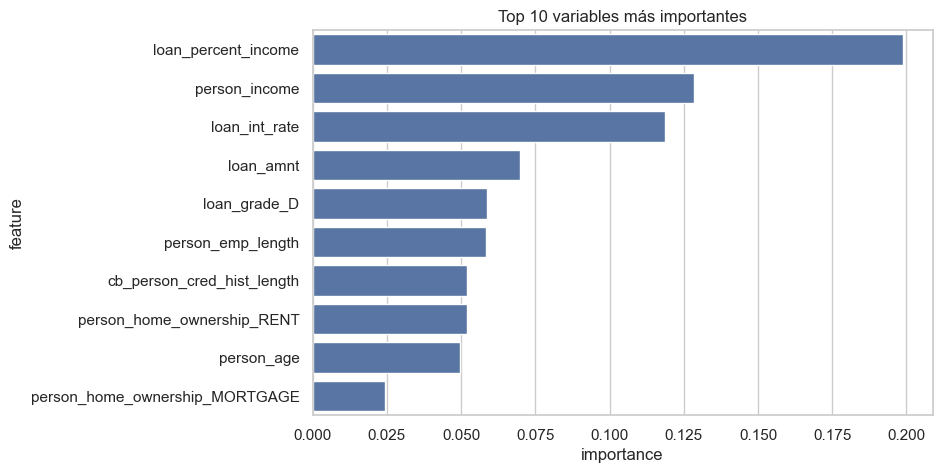

In [41]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=feat_importance.head(10),
    x="importance",
    y="feature"
)
plt.title("Top 10 variables más importantes")
plt.show()

## Interpretación del modelo con SHAP

Para complementar la evaluación cuantitativa, se incorpora un análisis interpretativo mediante SHAP (SHapley Additive exPlanations).

Esta técnica permite identificar la contribución de cada variable en las predicciones del modelo, facilitando la explicabilidad del sistema.

### Selección de muestra

Se utiliza una muestra del conjunto de prueba para facilitar el cálculo e interpretación de SHAP.

In [42]:
import shap
X_shap = X_test_final.sample(min(500, len(X_test_final)), random_state=42)
X_shap.shape

(500, 26)

### Creación del explicador

Se construye el explicador SHAP para el modelo seleccionado.

In [43]:
explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_shap)

In [44]:
if isinstance(shap_values, list):
    shap_values_class1 = shap_values[1]
else:
    shap_values_class1 = shap_values

### Importancia global de variables

Se visualiza el impacto global de las variables sobre las predicciones del modelo.

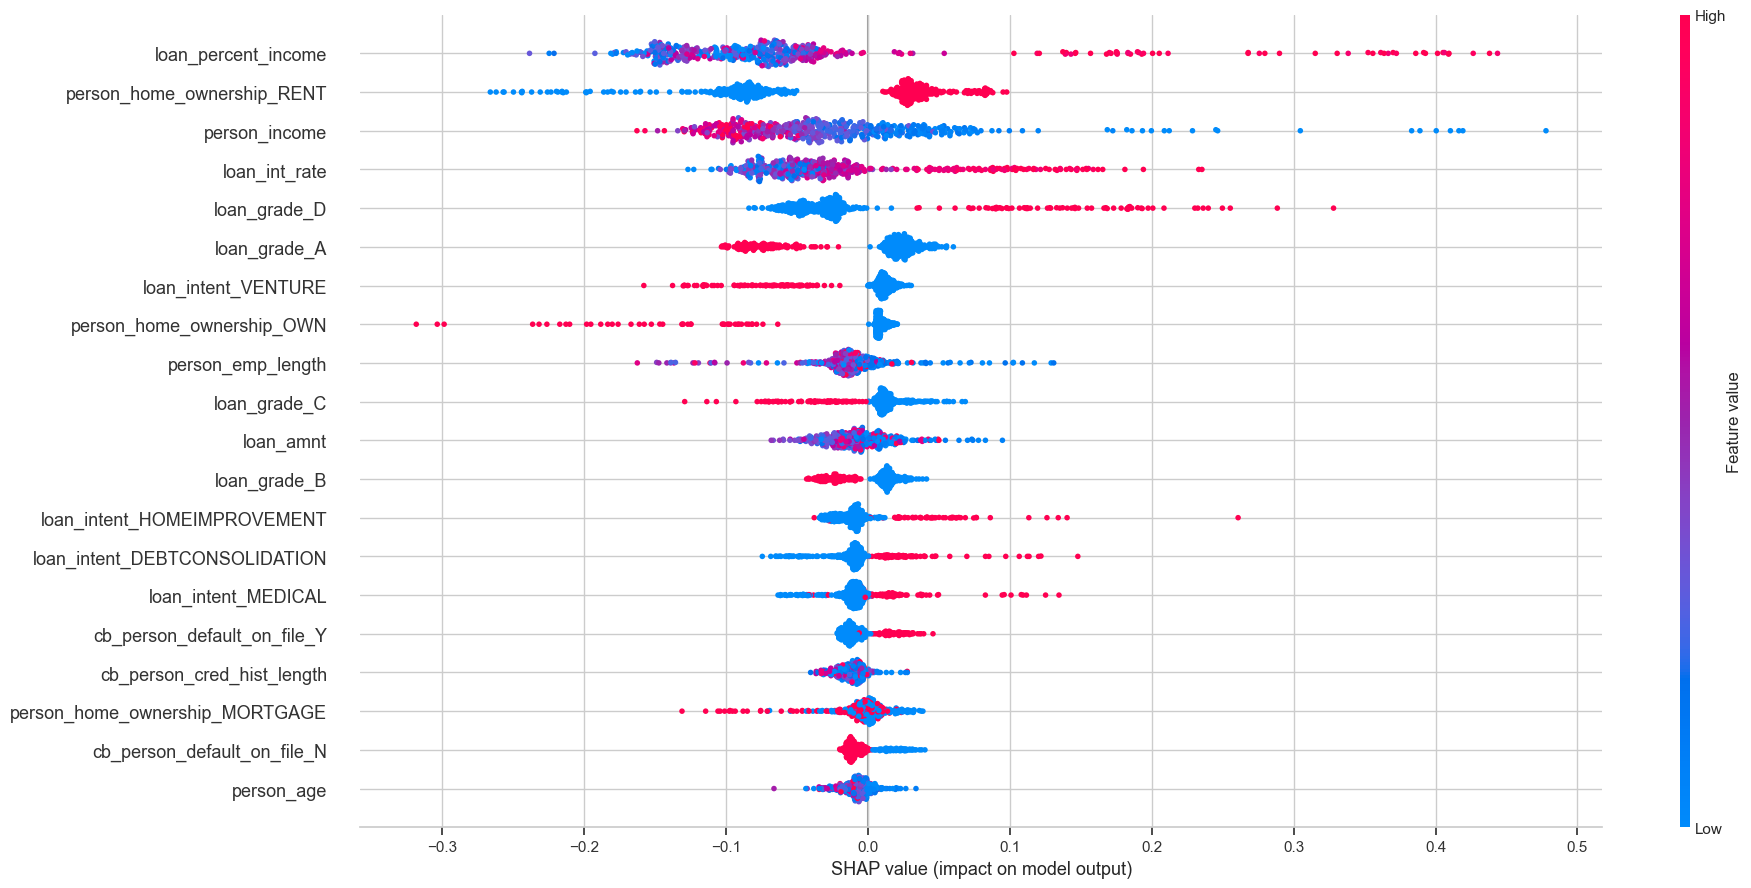

In [54]:
shap.summary_plot(
    shap_values_class1,
    X_shap,
    show=False
)

plt.gcf().set_size_inches(30, 9)  
plt.show()

## Conclusiones del análisis global con SHAP

El análisis mediante SHAP permite comprender cómo influyen las variables en las predicciones del modelo, considerando tanto la magnitud como la dirección de su impacto.

En el caso de `person_income`, se observa una relación clara: valores bajos de ingreso tienden a aumentar la probabilidad de incumplimiento, mientras que valores altos contribuyen a reducir dicho riesgo. Esto confirma que la capacidad económica del solicitante es un factor determinante en la evaluación crediticia.

Por otro lado, la variable `person_age` presenta un impacto mucho menor, sin una tendencia definida, lo que sugiere que no es un factor relevante dentro del modelo en comparación con variables financieras.

En general, el modelo se apoya principalmente en variables relacionadas con la situación económica del cliente, lo cual es coherente con la lógica del problema. Esto es una señal positiva, ya que indica que el modelo está aprendiendo patrones consistentes con la realidad del dominio.

Además, este tipo de análisis permite no solo interpretar el modelo, sino también validar que sus decisiones son razonables, lo que aporta mayor confianza en su uso dentro de un contexto aplicado.


### Ranking global de variables

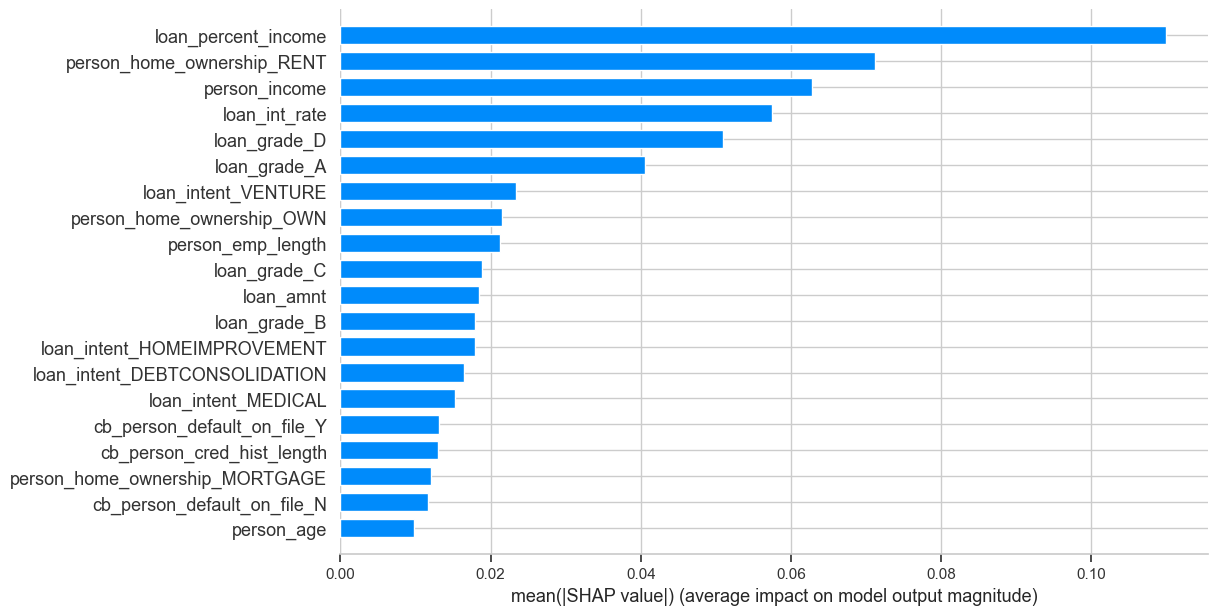

In [46]:
shap_values_arr = np.array(shap_values)

if shap_values_arr.ndim == 3:
    shap_values_class1 = shap_values_arr[:, :, 1]
elif isinstance(shap_values, list):
    shap_values_class1 = shap_values[1]
else:
    shap_values_class1 = shap_values

shap.summary_plot(
    shap_values_class1,
    X_shap,
    plot_type="bar",
    show=False
)

plt.gcf().set_size_inches(16, 6)
plt.show()

### Interpretación del ranking global de variables

El gráfico de barras permite identificar de forma más clara cuáles son las variables que tienen mayor peso en las predicciones del modelo.

La variable más influyente es `loan_percent_income`, lo que indica que la proporción del ingreso comprometida por el préstamo es el factor que más incide en la estimación del incumplimiento. Este resultado es coherente con la lógica financiera del problema, ya que mientras mayor sea la carga del préstamo sobre el ingreso del solicitante, mayor es el riesgo de no poder cumplir con los pagos.

En segundo lugar, destaca `person_home_ownership_RENT`, lo que sugiere que la condición habitacional del solicitante también aporta información relevante al modelo. Luego aparecen variables como `person_income` y `loan_int_rate`, que reflejan la capacidad económica del cliente y el costo del crédito, respectivamente.

También se observan variables relacionadas con la calificación del préstamo (`loan_grade_D`, `loan_grade_A`, `loan_grade_C`, `loan_grade_B`) y con el propósito del crédito (`loan_intent_VENTURE`, `loan_intent_HOMEIMPROVEMENT`, `loan_intent_DEBTCONSOLIDATION`, `loan_intent_MEDICAL`), lo que muestra que el modelo no basa sus decisiones en un único factor, sino en una combinación de condiciones financieras y contextuales.

Por el contrario, variables como `person_age` o algunas relacionadas con historial y tipo de vivienda tienen un impacto menor en comparación con las variables principales.

En conjunto, este ranking confirma que el modelo está priorizando variables coherentes con el problema de riesgo crediticio, especialmente aquellas que reflejan la carga financiera del solicitante, su nivel de ingreso y ciertas características del préstamo.

### Explicación local de una predicción

Además del análisis global, resulta útil explicar una predicción individual del modelo.  
Para ello, se selecciona un caso del conjunto de prueba y se analiza cómo cada variable contribuye a aumentar o disminuir la probabilidad estimada de incumplimiento.

In [47]:
# Seleccionar una observación individual
fila = X_shap.iloc[[0]]

fila

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_MORTGAGE,person_home_ownership_OTHER,person_home_ownership_OWN,...,loan_intent_VENTURE,loan_grade_A,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_N,cb_person_default_on_file_Y
11140,-0.427163,0.093487,-0.18763,-1.202246,-1.09009,-1.312469,-0.442817,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


### Cálculo de valores SHAP para una observación

Se calculan los valores SHAP para una sola observación, con el fin de interpretar el aporte de cada variable a la predicción local del modelo.

In [48]:
# Calcular valores SHAP para una sola fila
shap_row_all = explainer.shap_values(fila)

# Ajustar formato según la salida del modelo y la versión de SHAP
if isinstance(shap_row_all, list):
    shap_row = np.array(shap_row_all[1][0]).flatten()
    base_value = explainer.expected_value[1]
else:
    shap_row_all = np.array(shap_row_all)

    if shap_row_all.ndim == 3:
        shap_row = shap_row_all[0, :, 1].flatten()
        base_value = explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value
    elif shap_row_all.ndim == 2:
        shap_row = shap_row_all[0].flatten()
        base_value = explainer.expected_value
    else:
        shap_row = shap_row_all.flatten()
        base_value = explainer.expected_value

if isinstance(base_value, (list, np.ndarray)):
    base_value = np.array(base_value).flatten()[0]

### Verificación de dimensiones

Antes de generar la visualización, se verifica que la cantidad de valores SHAP coincida con la cantidad de variables del caso analizado.

In [49]:
print("Shape shap_row:", np.array(shap_row).shape)
print("Base value:", base_value)
print("Shape data:", fila.iloc[0].values.shape)
print("Número de variables:", len(fila.columns))

Shape shap_row: (26,)
Base value: 0.49994209441554616
Shape data: (26,)
Número de variables: 26


### Visualización local tipo waterfall

El gráfico waterfall muestra cómo cada variable desplaza la predicción desde el valor base del modelo hasta la predicción final del caso seleccionado.

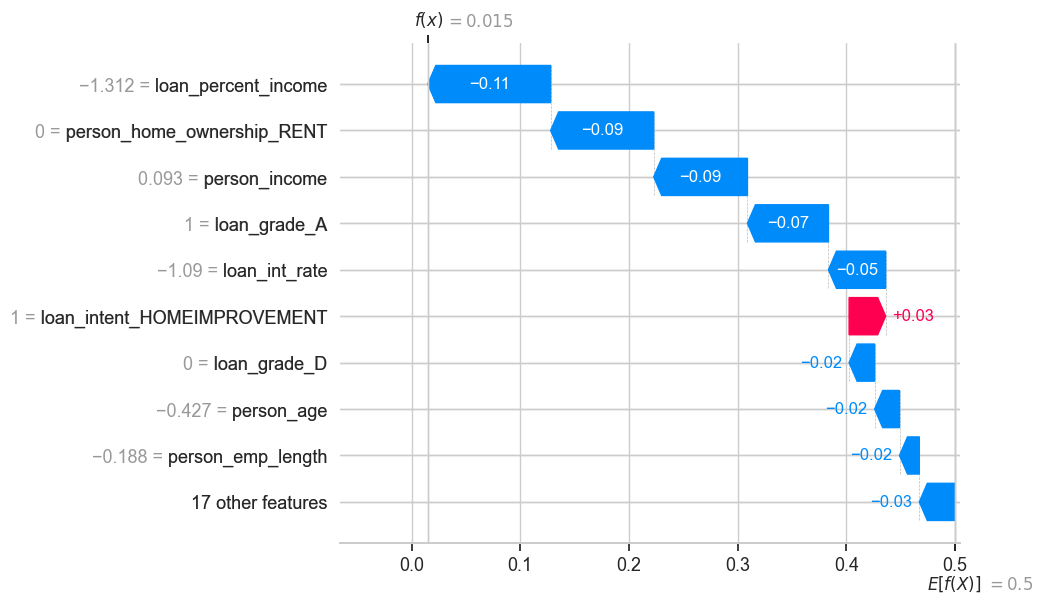

In [50]:
exp = shap.Explanation(
    values=shap_row,
    base_values=base_value,
    data=fila.iloc[0].values,
    feature_names=fila.columns.tolist()
)

shap.plots.waterfall(exp)

### Conclusión de la explicación local con SHAP

El gráfico tipo waterfall permite descomponer la predicción del modelo para un caso específico, mostrando cómo cada variable contribuye a aumentar o disminuir la probabilidad de incumplimiento.

En este caso, el valor base del modelo se sitúa alrededor de 0.5, mientras que la predicción final es muy baja (≈ 0.015), lo que indica que el modelo clasifica al cliente como de muy bajo riesgo.

Esta reducción en la probabilidad de incumplimiento se explica principalmente por variables asociadas a una menor carga financiera y mejor perfil crediticio. En particular, destaca el impacto de `loan_percent_income`, que reduce significativamente el riesgo (-0.11), seguido por variables como el tipo de vivienda (`person_home_ownership_RENT`), el nivel de ingresos (`person_income`) y una buena clasificación del préstamo (`loan_grade_A`).

Asimismo, una tasa de interés relativamente baja (`loan_int_rate`) también contribuye a disminuir el riesgo. En conjunto, estas variables reflejan un perfil financiero favorable para el solicitante.

Por otro lado, algunas variables aportan levemente al aumento del riesgo, como el propósito del préstamo (`loan_intent_HOMEIMPROVEMENT`), aunque su impacto es menor en comparación con los factores que reducen la probabilidad de incumplimiento.

En síntesis, el modelo toma una decisión coherente desde el punto de vista financiero, priorizando variables relacionadas con la carga del crédito y la capacidad de pago del cliente, lo que refuerza la interpretabilidad y confiabilidad de sus predicciones.

### Guardar el modelo para su uso en el Front End

In [55]:
import joblib

joblib.dump(modelo_rf, "../app/model.pkl")
joblib.dump(encoder, "../app/encoder.pkl")

['../app/encoder.pkl']